# Notebook 4 — Imperfect recordings

*SWC ENC 2026 · ephys-one module · independent of Notebooks 5–7*

Notebook 3 fitted a parabola to perfect data. Real sweeps are not perfect: the
amplifier adds its own noise, the patch slowly loses channels during the experiment,
you never have as many sweeps as you'd like, and the digitiser only resolves so much.
Each of these bends or blurs the parabola in its own way. This notebook shows each
one, and builds the fix.

**In this notebook you will:**
1. See how **background noise** lifts the parabola, and subtract it.
2. See how **rundown** inflates the variance, and cure it with **successive
   differences**.
3. Measure how uncertain your estimates are with the **bootstrap**, and see how the
   uncertainty shrinks with the number of sweeps.
4. See what the **digitiser's resolution** does when the channels are very many.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import picopatch as pp

def fit_and_show(exp, var=None, baseline=0.0, title=""):
    # helper: fit the parabola (optionally with a supplied variance / baseline) and plot it
    mean, v = pp.isochrone_stats(exp.sweeps)
    if var is not None:
        v = var
    fit = pp.fit_parabola(mean, v, baseline)
    ax = pp.plotting.plot_variance_mean(mean, v, fit=fit, truth=exp.truth, t_ms=exp.t_ms, title=title)
    return fit, ax

## 1. Background noise lifts the parabola

Every recording has noise that has nothing to do with the channels: thermal noise in
the seal and the pipette, amplifier noise. Here we add white noise with a standard
deviation of 4 pA to every sample. Look at the sweeps *before* the step: previously
dead flat, now fuzzy.

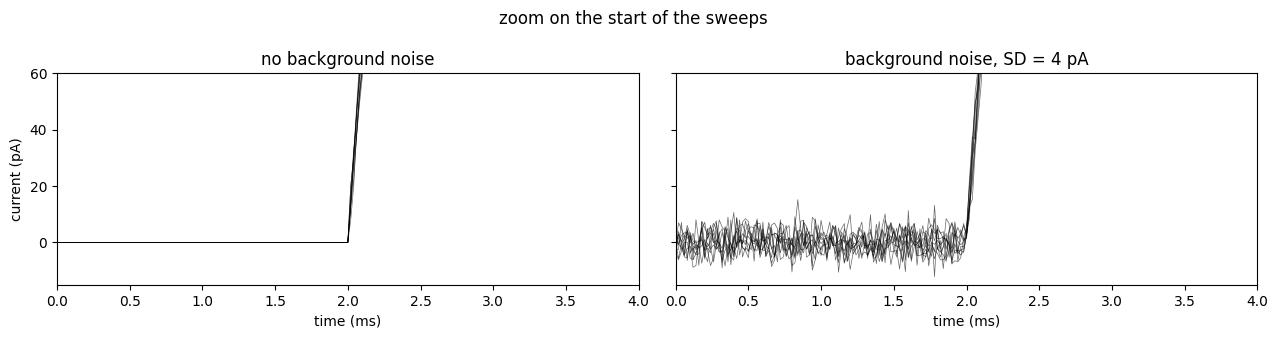

In [2]:
clean = pp.make_experiment(N=1000, i=1.0, n_sweeps=300, seed=0)
noisy = pp.make_experiment(N=1000, i=1.0, n_sweeps=300, noise_sd=4.0, seed=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.4), sharey=True)
for ax, e, name in [(axes[0], clean, "no background noise"), (axes[1], noisy, "background noise, SD = 4 pA")]:
    for k in range(10):
        ax.plot(e.t_ms, e.sweeps[k], color="k", lw=0.5, alpha=0.6)
    ax.set_xlim(0, 4); ax.set_ylim(-15, 60); ax.set_title(name); ax.set_xlabel("time (ms)")
axes[0].set_ylabel("current (pA)")
plt.suptitle("zoom on the start of the sweeps"); plt.tight_layout(); plt.show()

Independent noise adds its variance to every isochrone — the same amount,
$\sigma_{bg}^2 = 16$ pA², at every time point, whether channels are open or not. So
the parabola is **shifted up** by a constant. If you fit the plain parabola
$i\langle I\rangle - \langle I\rangle^2/N$ to a lifted curve, the fit is forced
through the origin and gets both $i$ and $N$ wrong:

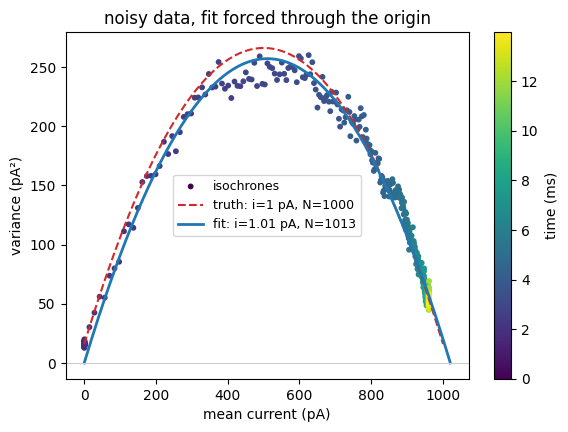

naive fit: NoiseFit(i=1.007 pA, N=1013, p_max=0.94, baseline=0 pA^2)


In [3]:
fit_raw, ax = fit_and_show(noisy, title="noisy data, fit forced through the origin")
plt.show()
print(f"naive fit: {fit_raw}")

The fix is simple because we can *measure* the background: before the step, no
channels are open, so all the variance there is background. Average the variance over
the pre-step samples, subtract it from every isochrone, and fit as before.

**Exercise 1** *(~5 min)*. Complete `baseline_variance`: the mean of the across-sweep
variance over the samples before the step (`exp.protocol.step_index` is the first
sample of the step). Then subtract it and refit.

> **Check / unstuck.** The baseline should be ≈ 16 pA², and the corrected fit should
> give $i \approx 1$ pA, $N \approx 1000$. Stuck? `pp.baseline_variance(sweeps,
> protocol)`, and `pp.fit_parabola(mean, var, baseline)` takes the offset directly.

baseline variance = 15.9 pA²   (true noise SD 4 pA -> 16 pA²)
corrected fit: NoiseFit(i=0.957 pA, N=1051, p_max=0.96, baseline=0 pA^2)


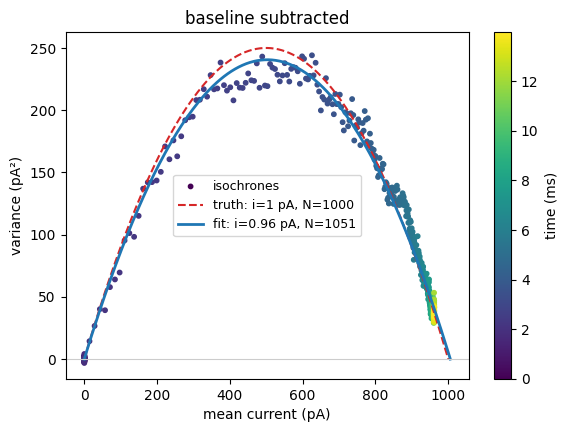

In [4]:
def baseline_variance(sweeps, protocol):
    n_pre = protocol.step_index
    _, var_pre = pp.isochrone_stats(sweeps[:, :n_pre])
    return var_pre.mean()

base = baseline_variance(noisy.sweeps, noisy.protocol)
print(f"baseline variance = {base:.1f} pA²   (true noise SD 4 pA -> 16 pA²)")

mean, var = pp.isochrone_stats(noisy.sweeps)
fit_corr = pp.fit_parabola(mean, var - base)           # subtract, then fit as in Notebook 3
print(f"corrected fit: {fit_corr}")
pp.plotting.plot_variance_mean(mean, var - base, fit=fit_corr, truth=clean.truth, t_ms=noisy.t_ms,
                               title="baseline subtracted")
plt.show()

<details>
<summary><b>▸ Go deeper: fitting the offset instead of subtracting it (optional)</b></summary>

Subtracting a measured baseline assumes the background is the same during the step as
before it. If you'd rather let the data decide, add a third regressor — a column of
ones — to the design matrix of Notebook 3:
$\sigma^2 = c + i\langle I\rangle - \langle I\rangle^2/N$. The fit then returns
$c$ as well. It costs a little precision (three parameters from the same dots) and
is the standard choice when there is no clean pre-step baseline.
</details>

## 2. Rundown inflates the variance

Over a long experiment the patch changes: channels wash out, get modified, or die.
The current gets smaller from sweep to sweep — **rundown**. Here 20% of the channels
are lost between the first and last sweep. Look at the plateau current against sweep
number:

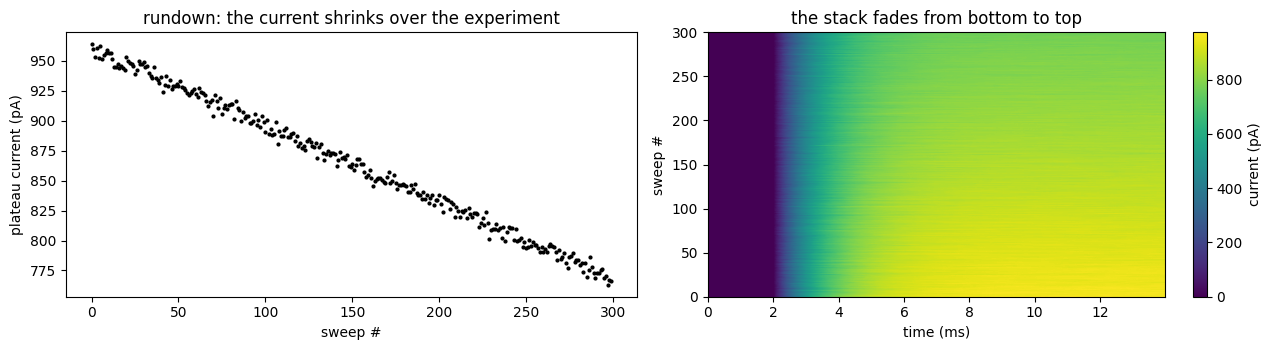

In [5]:
rund = pp.make_experiment(N=1000, i=1.0, n_sweeps=300, rundown=0.2, seed=3)
plateau = rund.sweeps[:, -200:].mean(axis=1)                # mean plateau current of each sweep

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
axes[0].plot(plateau, ".", color="k", ms=4)
axes[0].set_xlabel("sweep #"); axes[0].set_ylabel("plateau current (pA)")
axes[0].set_title("rundown: the current shrinks over the experiment")
pp.plotting.plot_sweep_image(rund, ax=axes[1], title="the stack fades from bottom to top")
plt.tight_layout(); plt.show()

Why is this a problem? The variance across sweeps is supposed to measure *channel
noise* — sweep-to-sweep scatter around a fixed mean. But now the mean itself drifts
across sweeps, and that drift adds to the across-sweep variance. Worse, it adds
*most* where the current is largest (a 20% change of 960 pA is far bigger than a 20%
change of 50 pA), so the right-hand side of the parabola is thrown upward and the
curve no longer bends back down:

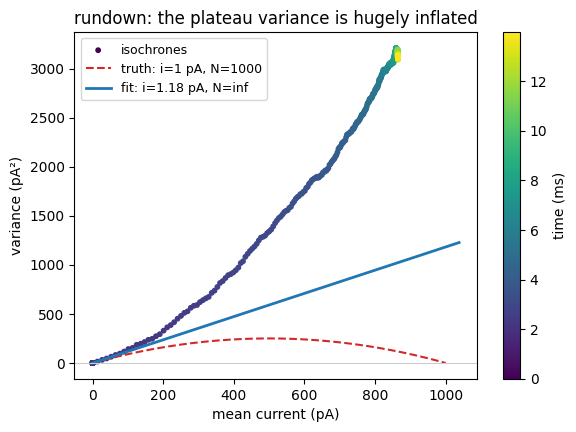

naive fit: NoiseFit(i=1.182 pA, N=inf, p_max=0.00, baseline=0 pA^2)   <- N is nonsense


In [6]:
fit_rd, ax = fit_and_show(rund, title="rundown: the plateau variance is hugely inflated")
plt.show()
print(f"naive fit: {fit_rd}   <- N is nonsense")

The fix: don't compare every sweep to the grand mean; compare each sweep to **its
neighbour**. Consecutive sweeps have almost the same number of channels, so their
difference contains the channel noise but almost none of the drift. For two
independent draws the variance of the difference is twice the variance of one, so
halve it. The paper's recipe: form $y_k = (x_k - x_{k+1})/2$ for each pair of
consecutive sweeps, then

$$\sigma^2 = \frac{2}{n-1}\sum_{k=1}^{n-1}\left(y_k - \bar y\right)^2 .$$

**Exercise 2** *(~6 min)*. Complete `successive_difference_variance`. `np.diff(sweeps,
axis=0)` gives the consecutive differences. Use the formula above at each time point,
then refit.

> **Check / unstuck.** On the clean recording this should agree with the ordinary
> variance; on the rundown recording the parabola should close again and $N$ should
> come out near 900 — the *average* number of channels present over the experiment
> (1000 at the start, 800 at the end). Stuck? `pp.successive_difference_variance`.

clean data, plateau variance: ordinary 38.7  successive-difference 37.9  pA²


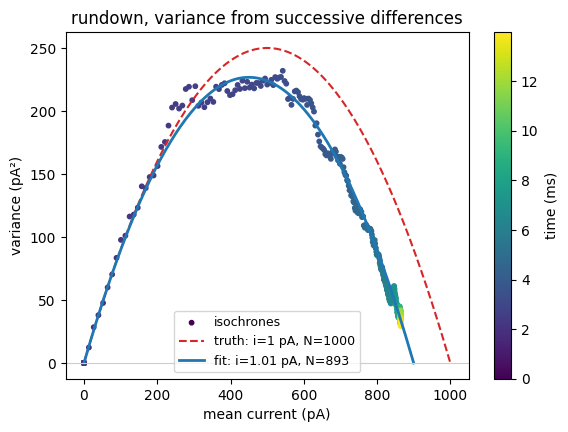

corrected fit: NoiseFit(i=1.008 pA, N=893, p_max=0.96, baseline=0 pA^2)   (average channels present: 900)


In [7]:
def successive_difference_variance(sweeps):
    y = np.diff(sweeps, axis=0) / 2.0
    n = sweeps.shape[0]
    return 2.0 / (n - 1) * ((y - y.mean(axis=0)) ** 2).sum(axis=0)

# sanity check on clean data: same answer as the ordinary variance
_, var_clean = pp.isochrone_stats(clean.sweeps)
print(f"clean data, plateau variance: ordinary {var_clean[-200:].mean():.1f}  "
      f"successive-difference {successive_difference_variance(clean.sweeps)[-200:].mean():.1f}  pA²")

var_sd = successive_difference_variance(rund.sweeps)
fit_sd, ax = fit_and_show(rund, var=var_sd, title="rundown, variance from successive differences")
plt.show()
print(f"corrected fit: {fit_sd}   (average channels present: {rund.truth.n_active.mean():.0f})")

## 3. How many sweeps do you need? The bootstrap

Even with perfect data, the fit is only an *estimate*: a different set of 300 sweeps
would give slightly different numbers. How different? The **bootstrap** answers this
without any theory: resample the sweeps *with replacement* (pick 300 sweeps at random
from your 300, allowing repeats), refit, and repeat a few hundred times. The spread of
the refitted values is the uncertainty of your estimate.

**Exercise 3** *(~8 min)*. Complete `bootstrap_fit`: for each of `n_boot` rounds, draw
`n_sweeps` indices with `rng.integers(0, n_sweeps, n_sweeps)`, take those sweeps,
compute isochrone stats, fit, and record `i` and `N`. Then run it for recordings of
20, 100 and 500 sweeps and compare the spreads.

> **Check / unstuck.** The histograms should narrow as the number of sweeps grows;
> with 20 sweeps $N$ is barely constrained, with 500 it's within a few percent.
> Stuck? `pp.bootstrap_fit(sweeps, n_boot)` returns `(i_samples, N_samples)`.

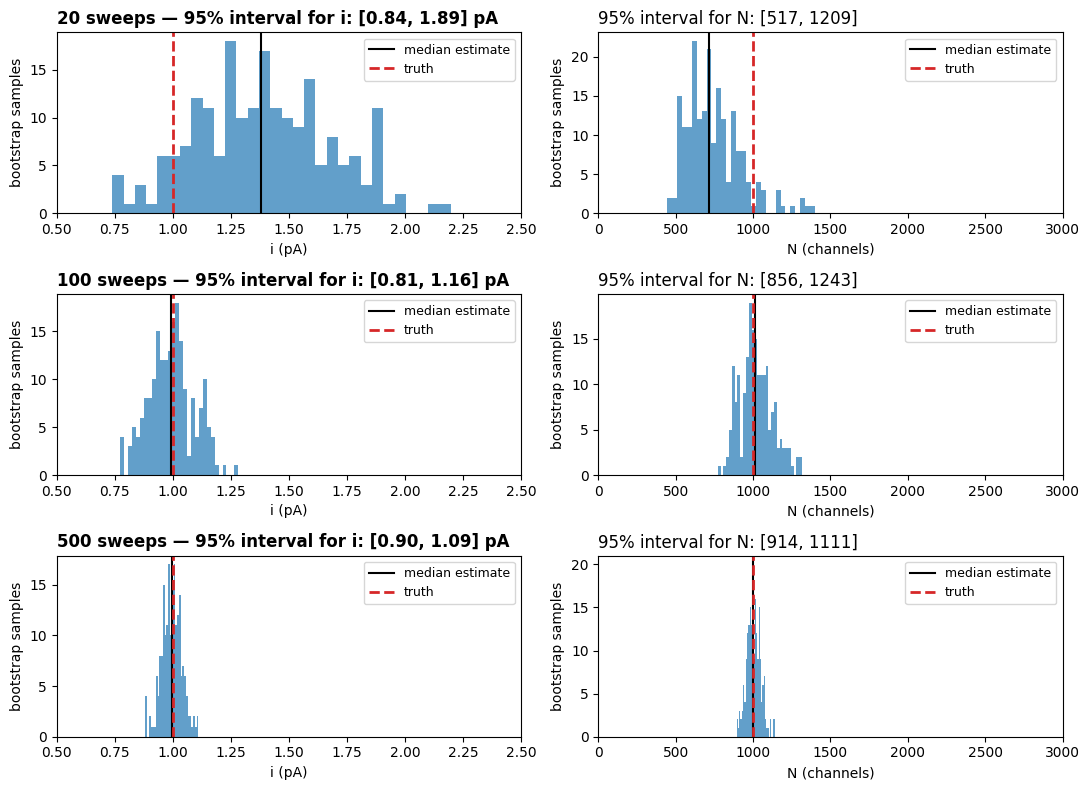

In [8]:
def bootstrap_fit(sweeps, n_boot=200, rng=None):
    rng = np.random.default_rng(rng)
    n = sweeps.shape[0]
    i_s, N_s = np.empty(n_boot), np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        m, v = pp.isochrone_stats(sweeps[idx])
        f = pp.fit_parabola(m, v)
        i_s[b], N_s[b] = f.i, f.N
    return i_s, N_s

fig, axes = plt.subplots(3, 2, figsize=(11, 8))
for row, n_sw in zip(axes, [20, 100, 500]):
    e = pp.make_experiment(N=1000, i=1.0, n_sweeps=n_sw, seed=7)
    i_s, N_s = bootstrap_fit(e.sweeps, n_boot=200, rng=0)
    pp.plotting.plot_bootstrap(i_s, N_s, truth=e.truth, axes=row)
    lo, hi = np.percentile(N_s[np.isfinite(N_s)], [2.5, 97.5])
    ilo, ihi = np.percentile(i_s, [2.5, 97.5])
    row[0].set_title(f"{n_sw} sweeps — 95% interval for i: [{ilo:.2f}, {ihi:.2f}] pA", loc="left", fontweight="bold")
    row[1].set_title(f"95% interval for N: [{lo:.0f}, {hi:.0f}]", loc="left")
    row[0].set_xlim(0.5, 2.5); row[1].set_xlim(0, 3000)          # shared axes so the shrinking is visible
plt.tight_layout(); plt.show()

With 20 sweeps both estimates are poor — $i$ can be off by 50%, $N$ by a factor of two.
Both intervals shrink roughly as $1/\sqrt{n_{sweeps}}$: four times the sweeps, half
the error bar. The paper's rule of thumb matches what you see: 10 sweeps give ~20%
errors, 1000 sweeps ~4%. The bootstrap is cheap, so **always report an interval**,
not just a number; Notebook 8 does this for every estimate.

<details>
<summary><b>▸ Go deeper: why the bootstrap works (optional)</b></summary>

Your 300 sweeps are a sample from the (unknown) distribution of possible sweeps. The
best stand-in for that distribution is the sample itself. Drawing from it with
replacement mimics "running the experiment again"; the variability of the refitted
estimates across those pseudo-experiments approximates the variability you would see
across real repeats. The key assumption is that the sweeps are independent and
identically distributed — which rundown violates, so with successive differences one
resamples *pairs* of consecutive sweeps instead (that's what `pp.bootstrap_fit` does
when given `var_fn=pp.successive_difference_variance`).
</details>

## 4. The digitiser's resolution

One last, quieter limitation. The analog-to-digital converter represents the current
in discrete **counts**; a 12-bit converter has 4096 of them across its full range. If
you set the range so that the whole macroscopic current spans 1000 counts, then with
10 channels one channel is 100 counts — the fluctuations are resolved beautifully.
With 10 000 channels one count is *10 channels*, and the fluctuations, which are only
a few channels in size (remember $1/\sqrt N$), are rounded away. The paper's Fig. 8
shows the consecutive-sweep differences in these two cases; here is ours:

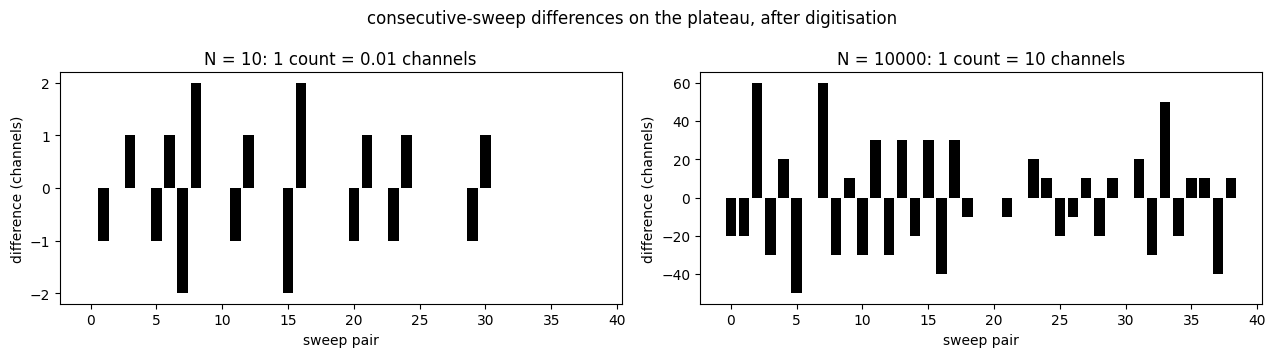

N =    10, resolution  0.01 pA:  fit -> NoiseFit(i=1.068 pA, N=9, p_max=0.96, baseline=0 pA^2)
N = 10000, resolution    10 pA:  fit -> NoiseFit(i=0.961 pA, N=10412, p_max=0.96, baseline=0 pA^2)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
for ax, N in zip(axes, [10, 10000]):
    step = N * 1.0 / 1000                                   # full-scale current = 1000 counts
    e = pp.make_experiment(N=N, i=1.0, n_sweeps=40, adc_step=step, seed=N)
    k = e.n_samples - 1                                     # last isochrone (plateau)
    diffs = np.diff(e.sweeps[:, k]) / 1.0                   # consecutive-sweep differences, in channels
    ax.bar(np.arange(len(diffs)), diffs, color="k")
    ax.set_xlabel("sweep pair"); ax.set_ylabel("difference (channels)")
    ax.set_title(f"N = {N}: 1 count = {step:g} channel{'s' if step != 1 else ''}")
plt.suptitle("consecutive-sweep differences on the plateau, after digitisation"); plt.tight_layout(); plt.show()

for N in [10, 10000]:
    step = N * 1.0 / 1000
    e = pp.make_experiment(N=N, i=1.0, n_sweeps=500, adc_step=step, seed=N)
    print(f"N = {N:5d}, resolution {step:5g} pA:  fit -> {pp.fit_parabola(*pp.isochrone_stats(e.sweeps))}")

With 10 000 channels every difference is a multiple of 10 channels — the true
fluctuations are smaller than one count. The fix is experimental, not computational:
use the gain and range to put as many counts as possible on the *fluctuations*, not
on the full current (e.g. a wider dynamic range, or offsetting the plateau).

**Where we are.** Four ways real data depart from the ideal, four fixes: subtract the
pre-step baseline variance; use successive differences when the current runs down;
bootstrap to put error bars on everything; and mind the resolution when $N$ is
large. All four are built into `pp.count_channels(exp, subtract_baseline=True,
rundown_correction=True)`, which Notebook 8 will lean on.